In [ ]:
!pip install gymnasium[classic_control]


In [ ]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

'''class QNetwork(nn.Module):  # Q network
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

class ReplayBuffer: # replay buffer
    def __init__(self, capacity=10000):
        self.buffer = []
        self.capacity = capacity

    def push(self, s, a, r, ns, d): # pushing into buffer
        s = np.array(s, dtype=np.float32).flatten()
        ns = np.array(ns, dtype=np.float32).flatten()

        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size): # sampling randomly from buffer
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.stack(states), actions, rewards, np.stack(next_states), dones

env = gym.make("MountainCar-v0")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim)
target_net = QNetwork(state_dim, action_dim)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=0.001)
buffer = ReplayBuffer(50000)

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
batch_size = 64
target_update = 100
episodes = 400

rewards_history = []

for ep in range(episodes):
    state, _ = env.reset()  # Gymnasium reset returns (state, info)
    done = False
    total_reward = 0

    while not done:
        # Choose action (epsilon-greedy)
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = q_net(torch.FloatTensor(state))
                action = torch.argmax(q_values).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated  # Combine termination signals
        buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        # ------------------- Learn from experience -------------------
        if len(buffer.buffer) > batch_size:
            s, a, r, ns, d = buffer.sample(batch_size)
            s = torch.FloatTensor(s)
            ns = torch.FloatTensor(ns)
            a = torch.LongTensor(a)
            r = torch.FloatTensor(r)
            d = torch.FloatTensor(d)

            q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                next_q = target_net(ns).max(1)[0]
                target = r + gamma * next_q * (1 - d)
            loss = nn.MSELoss()(q_values, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Update target network periodically
    if ep % target_update == 0:
        target_net.load_state_dict(q_net.state_dict())

    # Decay epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)
    rewards_history.append(total_reward)

    print(f"Episode {ep+1}/{episodes}, Reward: {total_reward}, Epsilon: {epsilon:.2f}")

# ------------------- Plot learning curve -------------------
plt.plot(rewards_history)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('DQN Learning Curve - MountainCar-v0')
plt.show()'''


'class QNetwork(nn.Module):\n    def __init__(self, state_dim, action_dim):\n        super(QNetwork, self).__init__()\n        self.net = nn.Sequential(\n            nn.Linear(state_dim, 128),\n            nn.ReLU(),\n            nn.Linear(128, 128),\n            nn.ReLU(),\n            nn.Linear(128, action_dim)\n        )\n\n    def forward(self, x):\n        return self.net(x)\n\n# ------------------- Replay Buffer -------------------\nclass ReplayBuffer:\n    def __init__(self, capacity=10000):\n        self.buffer = []\n        self.capacity = capacity\n\n    def push(self, s, a, r, ns, d):\n        s = np.array(s, dtype=np.float32).flatten()\n        ns = np.array(ns, dtype=np.float32).flatten()\n\n        if len(self.buffer) >= self.capacity:\n            self.buffer.pop(0)\n        self.buffer.append((s, a, r, ns, d))\n\n    def sample(self, batch_size):\n        batch = random.sample(self.buffer, batch_size)\n        states, actions, rewards, next_states, dones = zip(*batch)\n

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("MountainCar-v0") # our environment for experiments

num_actions = env.action_space.n # action space
num_states = env.observation_space.shape[0] # state space
print("Observation space:", env.observation_space)
print(f"Action space has {num_actions} actions:", env.action_space)
print("Meaning of actions: 0=Left, 1=No push, 2=Right")

transitions = []

for episode in range(20): # running 20 episodes with random agent
    #print(f"Episode {episode + 1}")
    state, info = env.reset()
    done = False
    while not done: # exploring till not complete
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        state = np.array(state, dtype=np.float32).flatten()
        next_state = np.array(next_state, dtype=np.float32).flatten()
        transitions.append((state, action, reward, next_state))
        state = next_state  # move to next

data_list = []
for s, a, r, ns in transitions:
    data_list.append([s[0], s[1], a, r, ns[0], ns[1]])

data_matrix = np.array(data_list, dtype=np.float32)

#print("\nData matrix shape:", data_matrix.shape)
#print("First 5 rows:\n", data_matrix[:40])


Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space has 3 actions: Discrete(3)
Meaning of actions: 0=Left, 1=No push, 2=Right


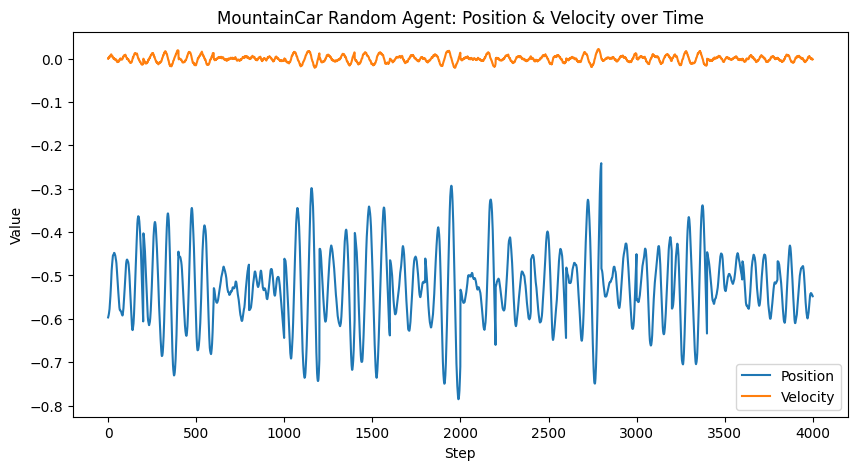

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data_matrix[:,0], label='Position')
plt.plot(data_matrix[:,1], label='Velocity')
plt.title("MountainCar Random Agent: Position & Velocity over Time")
plt.xlabel("Step")
plt.ylabel("Value")
plt.legend()
plt.show()

Observations:


*   The position fluctuates mostly between approximately -0.8 and -0.3, never reaching the goal at the right side of the mountain
*   The movement appears oscillatory, showing repeated small back-and-forth motions, typical of a random agent failing to gain enough momentum to climb the hill.



*   The agent is “stuck” in the valley, unable to reach the goal due to lack of coordinated acceleration
*   DUe to this we never see position 0.5 and a non zero reward, everytime we see -1 as shown above





In [ ]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim

env = gym.make("MountainCar-v0")
num_actions = env.action_space.n
num_states = env.observation_space.shape[0]

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = []
        self.capacity = capacity

    def push(self, s, a, r, ns, d):
        s = np.array(s, dtype=np.float32).flatten()
        ns = np.array(ns, dtype=np.float32).flatten()
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        positions = np.array([s[0] for (s, _, _, _, _) in self.buffer])
        priorities = (positions - positions.min()) + 1e-3
        priorities /= priorities.sum() # Priority proportional to position

        indices = np.random.choice(len(self.buffer), batch_size, p=priorities)
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


q_net = QNetwork(num_states, num_actions) # initialising network and other hyper parameters
target_net = QNetwork(num_states, num_actions)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=0.004) # adam optimizer for optimizing network
loss_fn = nn.SmoothL1Loss()  # Huber loss used

buffer = ReplayBuffer(10000)
gamma = 0.99
num_episodes = 1000
update_target_every = 10
max_steps = 500
batch_size = 128
epsilon = 0.9
epsilon_decay = 0.995
epsilon_min = 0.2

episode_rewards = []        # store total reward per episode
mean_rewards = []           # mean of last n episodes
best_mean_reward = -float('inf')
n = 50                      # number of episodes to compute running mean
steps_done = []             # cumulative steps for x-axis
total_steps = 0

for episode in range(num_episodes): # training loop, over all episodes
    state, info = env.reset()
    done = False
    total_reward = 0
    t = 0
    max_pos = state[0]

    while not done and t < max_steps: # episode continues till it goes on
        t += 1
        max_pos = max(max_pos, state[0])

        if np.random.random() < epsilon: # using epsilon greedy strategy for action selection
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = q_net(torch.FloatTensor(state).unsqueeze(0))
                action = torch.argmax(q_values).item()

        next_state, reward, terminated, truncated, info = env.step(action) # action used and next states are received
        done = terminated or truncated

        reward_shaping = (next_state[0] - state[0]) * 10 + abs(next_state[1]) * 0.5 # our own reward shaping, just for training
        if state[0] < -0.4:  # encourage moving left at start
          reward_shaping += -state[1] * 2
        position_bonus = max(0, next_state[0] + 0.5) * 3  # encourage rightmost
        reward_train = reward + reward_shaping + position_bonus


        buffer.push(state, action, reward_train, next_state, done) # pushing in buffer
        state = next_state
        total_reward += reward

        if len(buffer) >= batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)

            states = torch.FloatTensor(states)
            actions = torch.LongTensor(actions)
            rewards = torch.FloatTensor(rewards)
            next_states = torch.FloatTensor(next_states)
            dones = torch.FloatTensor(dones)

            with torch.no_grad(): # double DQN
                next_actions = q_net(next_states).argmax(1)
                next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
                targets = rewards + (1 - dones) * gamma * next_q_values

            q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze() # using Q values for deciding next action

            # Huber loss
            loss = loss_fn(q_values, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay) # decreasing epsilon for next episode

    episode_rewards.append(total_reward)
    total_steps += t
    steps_done.append(total_steps)

    if len(episode_rewards) >= n: # reward storing for plotting
      mean_n = np.mean(episode_rewards[-n:])
    else:
      mean_n = np.mean(episode_rewards)
    mean_rewards.append(mean_n)

    best_mean_reward = max(best_mean_reward, mean_n)

    if episode % update_target_every == 0:
        target_net.load_state_dict(q_net.state_dict()) # updating network

    print(f"Episode {episode}: Max Pos = {max_pos:.3f}, Total Reward = {total_reward:.2f}, Eps = {epsilon:.3f}")


Episode 0: Max Pos = -0.334, Total Reward = -200.00, Eps = 0.895
Episode 1: Max Pos = -0.333, Total Reward = -200.00, Eps = 0.891
Episode 2: Max Pos = -0.413, Total Reward = -200.00, Eps = 0.887
Episode 3: Max Pos = -0.358, Total Reward = -200.00, Eps = 0.882
Episode 4: Max Pos = -0.252, Total Reward = -200.00, Eps = 0.878
Episode 5: Max Pos = -0.391, Total Reward = -200.00, Eps = 0.873
Episode 6: Max Pos = -0.422, Total Reward = -200.00, Eps = 0.869
Episode 7: Max Pos = -0.417, Total Reward = -200.00, Eps = 0.865
Episode 8: Max Pos = -0.275, Total Reward = -200.00, Eps = 0.860
Episode 9: Max Pos = -0.292, Total Reward = -200.00, Eps = 0.856
Episode 10: Max Pos = -0.271, Total Reward = -200.00, Eps = 0.852
Episode 11: Max Pos = -0.407, Total Reward = -200.00, Eps = 0.847
Episode 12: Max Pos = -0.310, Total Reward = -200.00, Eps = 0.843
Episode 13: Max Pos = -0.424, Total Reward = -200.00, Eps = 0.839
Episode 14: Max Pos = -0.315, Total Reward = -200.00, Eps = 0.835
Episode 15: Max Pos 

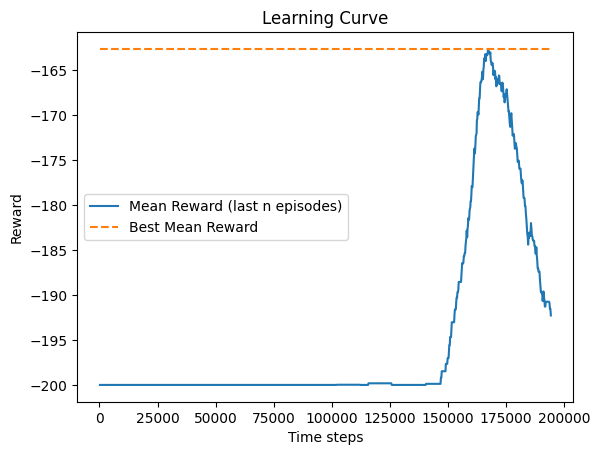

In [ ]:
import matplotlib.pyplot as plt

plt.plot(steps_done, mean_rewards, label='Mean Reward (last n episodes)')
plt.plot(steps_done, [best_mean_reward]*len(steps_done), '--', label='Best Mean Reward')
plt.xlabel('Time steps')
plt.ylabel('Reward')
plt.title('Learning Curve')
plt.legend()
plt.show()


In [ ]:
print(best_mean_reward)

-162.68


In [ ]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim

env = gym.make("MountainCar-v0")
num_actions = env.action_space.n
num_states = env.observation_space.shape[0]

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = []
        self.capacity = capacity

    def push(self, s, a, r, ns, d):
        s = np.array(s, dtype=np.float32).flatten()
        ns = np.array(ns, dtype=np.float32).flatten()
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        positions = np.array([s[0] for (s, _, _, _, _) in self.buffer])
        priorities = (positions - positions.min()) + 1e-3
        priorities /= priorities.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=priorities)
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


q_net = QNetwork(num_states, num_actions)
target_net = QNetwork(num_states, num_actions)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=0.004)
loss_fn = nn.SmoothL1Loss()

buffer = ReplayBuffer(50000)
gamma = 0.99
num_episodes = 1000
update_target_every = 10
max_steps = 500
batch_size = 128
epsilon = 0.9
epsilon_decay = 0.995
epsilon_min = 0.2

episode_rewards = []
mean_rewards = []
best_mean_reward = -float('inf')
n = 50
steps_done = []
total_steps = 0
best_mean_reward_all = []
mean_rewards_all = []
for buffer_number in [1000, 5000, 50000, 10000]:
  buffer = ReplayBuffer(buffer_number)
  q_net = QNetwork(num_states, num_actions)
  target_net = QNetwork(num_states, num_actions)
  target_net.load_state_dict(q_net.state_dict())
  target_net.eval()
  optimizer = optim.Adam(q_net.parameters(), lr=0.004)
  episode_rewards = []
  mean_rewards = []
  best_mean_reward = -float('inf')
  gamma = 0.99
  num_episodes = 1000
  update_target_every = 10
  max_steps = 500
  batch_size = 128
  epsilon = 0.9
  epsilon_decay = 0.995
  epsilon_min = 0.2

  episode_rewards = []
  mean_rewards = []
  best_mean_reward = -float('inf')
  n = 50
  steps_done = []
  total_steps = 0



  for episode in range(num_episodes):
      state, info = env.reset()
      done = False
      total_reward = 0
      t = 0
      max_pos = state[0]

      while not done and t < max_steps:
          t += 1
          max_pos = max(max_pos, state[0])

          if np.random.random() < epsilon:
              action = env.action_space.sample()
          else:
              with torch.no_grad():
                  q_values = q_net(torch.FloatTensor(state).unsqueeze(0))
                  action = torch.argmax(q_values).item()

          next_state, reward, terminated, truncated, info = env.step(action)
          done = terminated or truncated

          reward_shaping = (next_state[0] - state[0]) * 10 + abs(next_state[1]) * 0.5
          if state[0] < -0.4:
            reward_shaping += -state[1] * 2
          position_bonus = max(0, next_state[0] + 0.5) * 3
          reward_train = reward + reward_shaping + position_bonus

          buffer.push(state, action, reward_train, next_state, done)
          state = next_state
          total_reward += reward

          if len(buffer) >= batch_size:
              states, actions, rewards, next_states, dones = buffer.sample(batch_size)

              states = torch.FloatTensor(states)
              actions = torch.LongTensor(actions)
              rewards = torch.FloatTensor(rewards)
              next_states = torch.FloatTensor(next_states)
              dones = torch.FloatTensor(dones)

              with torch.no_grad():
                  next_actions = q_net(next_states).argmax(1)
                  next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
                  targets = rewards + (1 - dones) * gamma * next_q_values

              q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze()

              loss = loss_fn(q_values, targets)
              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

      epsilon = max(epsilon_min, epsilon * epsilon_decay)

      episode_rewards.append(total_reward)
      total_steps += t
      steps_done.append(total_steps)

      if len(episode_rewards) >= n:
        mean_n = np.mean(episode_rewards[-n:])
      else:
        mean_n = np.mean(episode_rewards)
      mean_rewards.append(mean_n)

      best_mean_reward = max(best_mean_reward, mean_n)

      if episode % update_target_every == 0:
          target_net.load_state_dict(q_net.state_dict())

      print(f"Episode {episode}: Max Pos = {max_pos:.3f}, Total Reward = {total_reward:.2f}, Eps = {epsilon:.3f}")
  best_mean_reward_all.append(best_mean_reward)
  mean_rewards_all.append(mean_rewards)
  print(best_mean_reward_all, buffer_number)



Episode 0: Max Pos = -0.441, Total Reward = -200.00, Eps = 0.895
Episode 1: Max Pos = -0.380, Total Reward = -200.00, Eps = 0.891
Episode 2: Max Pos = -0.456, Total Reward = -200.00, Eps = 0.887
Episode 3: Max Pos = -0.455, Total Reward = -200.00, Eps = 0.882
Episode 4: Max Pos = -0.428, Total Reward = -200.00, Eps = 0.878
Episode 5: Max Pos = -0.342, Total Reward = -200.00, Eps = 0.873
Episode 6: Max Pos = -0.370, Total Reward = -200.00, Eps = 0.869
Episode 7: Max Pos = -0.372, Total Reward = -200.00, Eps = 0.865
Episode 8: Max Pos = -0.414, Total Reward = -200.00, Eps = 0.860
Episode 9: Max Pos = -0.412, Total Reward = -200.00, Eps = 0.856
Episode 10: Max Pos = -0.341, Total Reward = -200.00, Eps = 0.852
Episode 11: Max Pos = -0.428, Total Reward = -200.00, Eps = 0.847
Episode 12: Max Pos = -0.444, Total Reward = -200.00, Eps = 0.843
Episode 13: Max Pos = -0.334, Total Reward = -200.00, Eps = 0.839
Episode 14: Max Pos = -0.402, Total Reward = -200.00, Eps = 0.835
Episode 15: Max Pos 

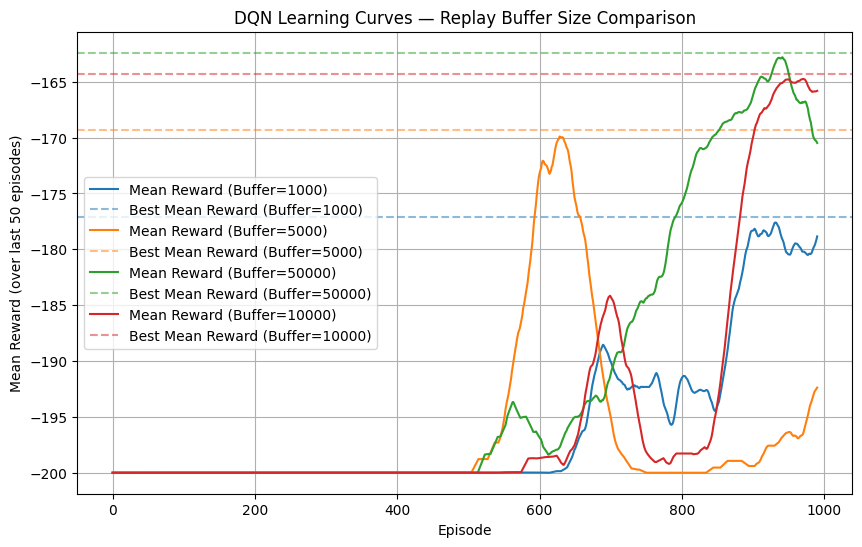

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
buffer_sizes = [1000, 5000, 50000, 10000]
n = 50  # s0 window size used

plt.figure(figsize=(10, 6))

for i, buffer_size in enumerate(buffer_sizes):
    mean_rewards = mean_rewards_all[i]
    best_mean = best_mean_reward_all[i]

    smooth_mean = np.convolve(mean_rewards, np.ones(10)/10, mode='valid')

    plt.plot(smooth_mean, label=f"Mean Reward (Buffer={buffer_size})")

    plt.axhline(best_mean, linestyle='--', color=plt.gca().lines[-1].get_color(),
                alpha=0.5, label=f"Best Mean Reward (Buffer={buffer_size})")

plt.title("DQN Learning Curves — Replay Buffer Size Comparison")
plt.xlabel("Episode")
plt.ylabel(f"Mean Reward (over last {n} episodes)")
plt.legend()
plt.grid(True)
plt.show()